# 3 — Matcher ONNX & TensorRT export

Exports **LightGlue / LighterGlue** matchers to ONNX and compiles FP16 TensorRT engines.

**Prerequisites:**
- `uv sync --group trt` (or `--all-groups`) for `polygraphy`, `tensorrt`
- `pip install onnxsim`
- A CUDA-capable GPU with TensorRT installed

**Prerequisite:** Run [1-export_extractors.ipynb](1-export_extractors.ipynb) and
[2-export_trt_extractors.ipynb](2-export_trt_extractors.ipynb) first.
The extractor `.fp16.engine` files in `weights/euroc/` are used in the visualisation (Section 5).

All export logic lives in `lightglue_dynamo.matcher_export` — no external repos needed.

In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
if CWD.name == "notebooks":
    LG = CWD.parent
    REPO_ROOT = LG.parent
elif CWD.name == "LightGlue-ONNX-Jetson":
    LG = CWD
    REPO_ROOT = CWD.parent
else:
    raise SystemExit("Run Jupyter with cwd = LightGlue-ONNX-Jetson or LightGlue-ONNX-Jetson/notebooks")

WEIGHTS = REPO_ROOT / "weights"
OUT_DIR = LG / "weights" / "euroc"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("LG      ", LG)
print("REPO_ROOT", REPO_ROOT)
print("WEIGHTS ", WEIGHTS, WEIGHTS.exists())
print("OUT_DIR ", OUT_DIR, OUT_DIR.exists())

LG       /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson
REPO_ROOT /home/ubuntu/Desktop/dl-vins-factory
WEIGHTS  /home/ubuntu/Desktop/dl-vins-factory/weights True
OUT_DIR  /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc True


In [2]:
import sys

if str(LG) not in sys.path:
    sys.path.insert(0, str(LG))

from lightglue_dynamo.matcher_export import export_matcher_onnx, load_lightglue_local
from lightglue_dynamo.extractor_export import build_extractor_trt_engine, simplify_onnx

print("lightglue_dynamo.matcher_export OK")
print("lightglue_dynamo.extractor_export OK")

lightglue_dynamo.matcher_export OK
lightglue_dynamo.extractor_export OK


### Matcher registry

| id | weights file | input_dim (D) | descriptor_dim | n_layers | num_heads | notes |
|----|-------------|---------------|----------------|----------|-----------|-------|
| superpoint | superpoint_lightglue.pth | 256 | 256 | 9 | 4 | old key format (auto-renamed) |
| aliked | aliked_lightglue.pth | 128 | 256 | 9 | 4 | ALIKED-n16 / n32 descriptors |
| raco | raco_aliked_lightglue.pth | 128 | 256 | 9 | 4 | RaCo keypoints + ALIKED descriptors |
| xfeat | xfeat-lighterglue.pt (`matcher.*`) | 64 | 96 | 6 | 1 | LighterGlue, joint checkpoint |

In [3]:
MATCHER_CONFIGS = [
    dict(
        id="superpoint",
        weights=WEIGHTS / "superpoint_lightglue.pth",
        input_dim=256, desc_dim=256, n_layers=9, num_heads=4,
        prefix=None,
    ),
    dict(
        id="aliked",
        weights=WEIGHTS / "aliked_lightglue.pth",
        input_dim=128, desc_dim=256, n_layers=9, num_heads=4,
        prefix=None,
    ),
    dict(
        id="raco",
        # Architecturally identical to aliked_lightglue: matches RaCo keypoints
        # paired with ALIKED 128-dim descriptors.
        weights=WEIGHTS / "raco_aliked_lightglue.pth",
        input_dim=128, desc_dim=256, n_layers=9, num_heads=4,
        prefix=None,
    ),
    dict(
        id="xfeat",
        # Joint checkpoint: extractor weights under "extractor.*",
        # LighterGlue matcher weights under "matcher.*".
        weights=WEIGHTS / "xfeat-lighterglue.pt",
        input_dim=64, desc_dim=96, n_layers=6, num_heads=1,
        prefix="matcher.",
    ),
]

K = 256  # fixed keypoint budget — must match the extractor export

print(f"{'id':12} {'input_dim':>9} {'desc_dim':>8} {'n_layers':>8} {'num_heads':>9}  weights")
for cfg in MATCHER_CONFIGS:
    status = "OK" if cfg["weights"].is_file() else "MISSING"
    print(f"{cfg['id']:12} {cfg['input_dim']:>9} {cfg['desc_dim']:>8} "
          f"{cfg['n_layers']:>8} {cfg['num_heads']:>9}  {cfg['weights'].name}  [{status}]")

id           input_dim desc_dim n_layers num_heads  weights
superpoint         256      256        9         4  superpoint_lightglue.pth  [OK]
aliked             128      256        9         4  aliked_lightglue.pth  [OK]
raco               128      256        9         4  raco_aliked_lightglue.pth  [OK]
xfeat               64       96        6         1  xfeat-lighterglue.pt  [OK]


### ONNX export

All four matchers share the same I/O contract:

```
Inputs:
  kpts0  (1, K, 2)   isotropic-normalised keypoints for image 0
  kpts1  (1, K, 2)   isotropic-normalised keypoints for image 1
  desc0  (1, K, D)   descriptors for image 0  (D = input_dim)
  desc1  (1, K, D)   descriptors for image 1

Outputs:
  matches0  (M, 2)   match pairs [idx_in_kpts0, idx_in_kpts1]
  mscores0  (M,)     match confidence scores
```

K is **fixed at 256**; M (number of matches) is dynamic.

Internally, `LightGlueExporter` concatenates the pair into `(2, K, *)` for the dynamo
model's batched-pair format, then strips the batch-index column from the match output.

In [4]:
onnx_paths: dict[str, Path] = {}

for cfg in MATCHER_CONFIGS:
    cid = cfg["id"]
    if not cfg["weights"].is_file():
        print(f"[SKIP] {cid}: weights not found at {cfg['weights']}")
        continue

    out = OUT_DIR / f"{cid}_lightglue_k{K}.onnx"
    print(f"Exporting {cid} matcher → {out.name} ...")

    export_matcher_onnx(
        cfg["weights"],
        out,
        num_keypoints=K,
        input_dim=cfg["input_dim"],
        descriptor_dim=cfg["desc_dim"],
        num_heads=cfg["num_heads"],
        n_layers=cfg["n_layers"],
        state_dict_prefix=cfg["prefix"],
        opset=17,
        device="cpu",
    )

    print(f"[OK]   {out.name}  ({out.stat().st_size / 1e6:.1f} MB)")
    onnx_paths[cid] = out

print(f"\nExported {len(onnx_paths)}/{len(MATCHER_CONFIGS)} matcher ONNX models.")

Exporting superpoint matcher → superpoint_lightglue_k256.onnx ...


/home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/.venv/lib/python3.10/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


[OK]   superpoint_lightglue_k256.onnx  (45.5 MB)
Exporting aliked matcher → aliked_lightglue_k256.onnx ...
[OK]   aliked_lightglue_k256.onnx  (45.7 MB)
Exporting raco matcher → raco_lightglue_k256.onnx ...
[OK]   raco_lightglue_k256.onnx  (45.7 MB)
Exporting xfeat matcher → xfeat_lightglue_k256.onnx ...
[OK]   xfeat_lightglue_k256.onnx  (4.5 MB)

Exported 4/4 matcher ONNX models.


### ONNX simplification (onnxsim)

Runs constant folding and dead-node elimination on each matcher ONNX.
Output: `*_sim.onnx` alongside the originals.

In [5]:
sim_paths: dict[str, Path] = {}

for cid, onnx_path in onnx_paths.items():
    sim_path = onnx_path.with_name(onnx_path.stem + "_sim.onnx")
    try:
        simplify_onnx(onnx_path, sim_path)
        ratio = sim_path.stat().st_size / onnx_path.stat().st_size
        print(f"[OK]   {onnx_path.name}")
        print(f"       -> {sim_path.name}  ({ratio:.1%} of original)")
        sim_paths[cid] = sim_path
    except Exception as exc:
        print(f"[ERR]  {onnx_path.name}: {exc} — using original")
        sim_paths[cid] = onnx_path

print(f"\nSimplified {sum(1 for p in sim_paths.values() if '_sim' in p.stem)}/{len(onnx_paths)} models.")

[OK]   superpoint_lightglue_k256.onnx
       -> superpoint_lightglue_k256_sim.onnx  (100.0% of original)
[OK]   aliked_lightglue_k256.onnx
       -> aliked_lightglue_k256_sim.onnx  (100.0% of original)
[OK]   raco_lightglue_k256.onnx
       -> raco_lightglue_k256_sim.onnx  (100.0% of original)
[OK]   xfeat_lightglue_k256.onnx
       -> xfeat_lightglue_k256_sim.onnx  (99.7% of original)

Simplified 4/4 models.


### TensorRT FP16 engine build

Builds one FP16 engine per simplified ONNX. Engines are saved as `*_sim.fp16.engine`.

In [6]:
engine_paths: dict[str, Path] = {}

for cid, sim_path in sim_paths.items():
    engine_path = sim_path.with_suffix(".fp16.engine")
    try:
        build_extractor_trt_engine(sim_path, engine_path, fp16=True)
        print(f"[OK]   {engine_path.name}  ({engine_path.stat().st_size / 1e6:.1f} MB)")
        engine_paths[cid] = engine_path
    except Exception as exc:
        print(f"[FAIL] {cid}: {exc}")

print(f"\nBuilt {len(engine_paths)}/{len(sim_paths)} matcher TRT engines.")

[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored
[I] TF32 is disabled by default. Turn on TF32 for better performance with minor accuracy differences.
[W] ModelImporter.cpp:804: Make sure output matches0 has Int64 binding.
[I] Configuring with profiles:[
        Profile 0:
            {kpts0 [min=[1, 256, 2], opt=[1, 256, 2], max=[1, 256, 2]],
             kpts1 [min=[1, 256, 2], opt=[1, 256, 2], max=[1, 256, 2]],
             desc0 [min=[1, 256, 256], opt=[1, 256, 256], max=[1, 256, 256]],
             desc1 [min=[1, 256, 256], opt=[1, 256, 256], max=[1, 256, 256]]}
    ]
[W] profileSharing0806 is on by default in TensorRT 10.0. This flag is deprecated and has no effect.
[I] Building engine with configuration:
    Flags                  | [FP16]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 15982.12 MiB, TACTIC_DRAM: 15982.12 M

### Test — ORT CUDA vs TRT

Runs both ORT CUDA (on the simplified ONNX) and TRT (on the engine) with the same
random inputs. Reports match counts, max absolute score difference, and TRT timing.

> Random inputs produce very few or zero mutual-nearest-neighbour matches — this
> test checks numerical consistency between ORT and TRT, not match quality.

In [7]:
import time

import numpy as np
import onnxruntime as ort
from polygraphy.backend.common import BytesFromPath
from polygraphy.backend.trt import EngineFromBytes, TrtRunner

PROVIDERS_ORT = ["CUDAExecutionProvider", "CPUExecutionProvider"]
N_WARMUP = 5
N_TIMED  = 20

rng = np.random.default_rng(42)  # fixed seed so ORT and TRT see identical inputs

for cid, engine_path in engine_paths.items():
    sim_path = sim_paths[cid]
    cfg = next(c for c in MATCHER_CONFIGS if c["id"] == cid)
    D = cfg["input_dim"]

    kpts0 = rng.random((1, K, 2), dtype=np.float32) * 2 - 1
    kpts1 = rng.random((1, K, 2), dtype=np.float32) * 2 - 1
    desc0 = rng.standard_normal((1, K, D)).astype(np.float32)
    desc1 = rng.standard_normal((1, K, D)).astype(np.float32)
    feed  = {"kpts0": kpts0, "kpts1": kpts1, "desc0": desc0, "desc1": desc1}

    # ORT reference
    ort_matches, ort_scores = None, None
    try:
        sess = ort.InferenceSession(str(sim_path), providers=PROVIDERS_ORT)
        ort_matches, ort_scores = sess.run(None, feed)
    except Exception as exc:
        print(f"[ORT SKIP] {cid}: {exc}")

    # TRT warmup + timed
    with TrtRunner(EngineFromBytes(BytesFromPath(str(engine_path)))) as runner:
        for _ in range(N_WARMUP):
            runner.infer(feed_dict=feed)
        t0 = time.perf_counter()
        for _ in range(N_TIMED):
            trt_out = runner.infer(feed_dict=feed)
        elapsed_ms = (time.perf_counter() - t0) / N_TIMED * 1000

    trt_matches = trt_out["matches0"]
    trt_scores  = trt_out["mscores0"]

    print(f"\n=== {cid}  TRT {elapsed_ms:.2f} ms/pair ===")
    print(f"  TRT  matches={trt_matches.shape}  scores={trt_scores.shape}")

    if ort_matches is not None:
        print(f"  ORT  matches={ort_matches.shape}")
        if ort_matches.shape == trt_matches.shape and ort_matches.shape[0] > 0:
            ort_idx = np.lexsort(ort_matches.T[::-1])
            trt_idx = np.lexsort(trt_matches.T[::-1])
            diff = float(np.abs(ort_scores[ort_idx] - trt_scores[trt_idx]).max())
            print(f"  max_score_diff={diff:.6f}")

[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/superpoint_lightglue_k256_sim.fp16.engine

=== superpoint  TRT 2.81 ms/pair ===
  TRT  matches=(6, 2)  scores=(6,)
  ORT  matches=(5, 2)
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/aliked_lightglue_k256_sim.fp16.engine

=== aliked  TRT 2.83 ms/pair ===
  TRT  matches=(15, 2)  scores=(15,)
  ORT  matches=(12, 2)
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/raco_lightglue_k256_sim.fp16.engine

=== raco  TRT 2.81 ms/pair ===
  TRT  matches=(1, 2)  scores=(1,)
  ORT  matches=(2, 2)
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/xfeat_lightglue_k256_sim.fp16.engine

=== xfeat  TRT 2.19 ms/pair ===
  TRT  matches=(0, 2)  scores=(0,)
  ORT  matches=(0, 2)


### ALIKED describe-at-keypoints — ONNX + TRT

Exports a second-stage ALIKED engine that accepts **external keypoints** (from RaCo)
and runs only the dense-feature backbone + SDDH head.

```
Inputs:  image  (2, 3, H, W)   float32  RGB [0, 1]
         kpts_n (2, K, 2)      float32  anisotropic-normalised to [-1, 1]
Output:  descriptors (2, K, 128)
```

Replaces the CPU PyTorch fallback in the RaCo visualisation.

In [8]:
from lightglue_dynamo.extractor_export import (
    export_aliked_describe_onnx,
    simplify_onnx,
    build_extractor_trt_engine,
)

ALIKED_N16_CK = WEIGHTS / "aliked-n16.pth"
K = 256
H, W = 480, 768

desc_onnx = OUT_DIR / f"aliked_n16_describe_b2_h{H}_w{W}_k{K}.onnx"
desc_sim  = OUT_DIR / f"aliked_n16_describe_b2_h{H}_w{W}_k{K}_sim.onnx"
desc_trt  = OUT_DIR / f"aliked_n16_describe_b2_h{H}_w{W}_k{K}_sim.fp16.engine"

print("Exporting ALIKED-n16 describe ONNX ...")
export_aliked_describe_onnx(
    desc_onnx,
    aliked_checkpoint=ALIKED_N16_CK,
    batch_size=2,
    height=H,
    width=W,
    max_keypoints=K,
)
print(f"[OK] {desc_onnx.name}  ({desc_onnx.stat().st_size / 1e6:.1f} MB)")

print("Simplifying ...")
simplify_onnx(desc_onnx, desc_sim)
print(f"[OK] {desc_sim.name}")

print("Building TRT FP16 engine ...")
build_extractor_trt_engine(desc_sim, desc_trt, fp16=True)
print(f"[OK] {desc_trt.name}  ({desc_trt.stat().st_size / 1e6:.1f} MB)")


Exporting ALIKED-n16 describe ONNX ...
loading /home/ubuntu/Desktop/dl-vins-factory/weights/aliked-n16.pth


/home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/lightglue_dynamo/models/aliked/blocks.py:59: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  max_offset = max(h, w) / 4.
/home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/lightglue_dynamo/models/aliked/blocks.py:215: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  wh = torch.tensor([[w - 1, h - 1]], device=x.device)
/home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/lightglue_dynamo/models/aliked/blocks.py:216: TracerWarning: Converting a tenso

[OK] aliked_n16_describe_b2_h480_w768_k256.onnx  (2.8 MB)
Simplifying ...
[OK] aliked_n16_describe_b2_h480_w768_k256_sim.onnx
Building TRT FP16 engine ...
[I] TF32 is disabled by default. Turn on TF32 for better performance with minor accuracy differences.
[I] Configuring with profiles:[
        Profile 0:
            {image [min=[2, 3, 480, 768], opt=[2, 3, 480, 768], max=[2, 3, 480, 768]],
             kpts_n [min=[2, 256, 2], opt=[2, 256, 2], max=[2, 256, 2]]}
    ]
[I] Building engine with configuration:
    Flags                  | [FP16]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 15982.12 MiB, TACTIC_DRAM: 15982.12 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
[I] Finished engine building in 50.765 seconds
[I] Saving engine to /home/ubuntu/Desktop/dl-vins-

### Match visualisation

Chains each extractor engine with its corresponding matcher engine and visualises
the matches on image pairs.
Timing is reported per stage: **extract**, **describe** (RaCo only), and **match**.


[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/superpoint_open_b2_h480_w768_k256_sim.fp16.engine
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/superpoint_lightglue_k256_sim.fp16.engine
SuperPoint + LightGlue: 137 matches  |  extract 8.0 ms  | match 3.9 ms  | total 12.0 ms


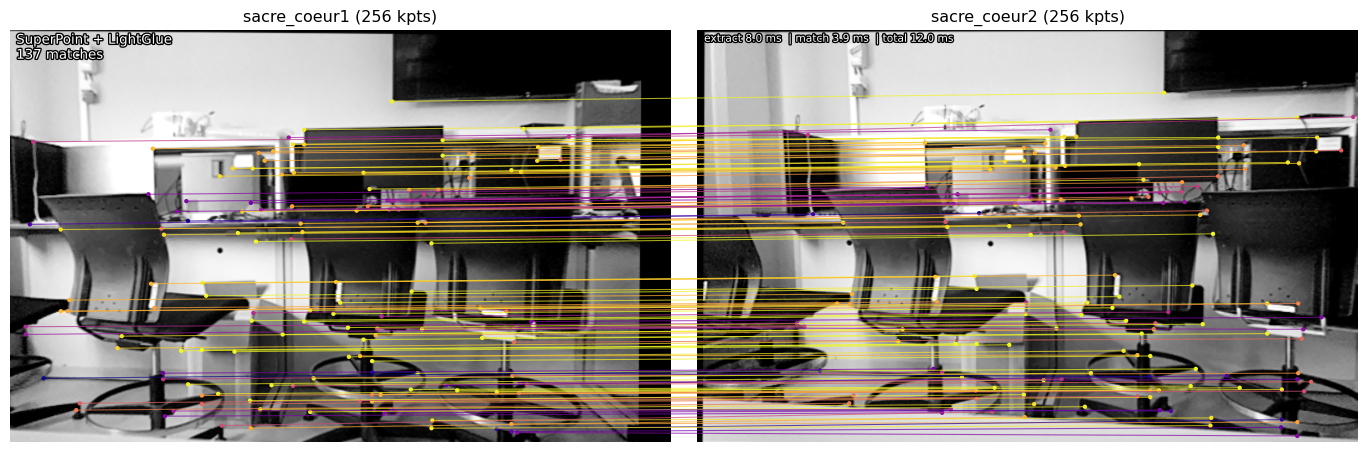

[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/aliked_n16_b2_h480_w768_k256_sim.fp16.engine
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/aliked_lightglue_k256_sim.fp16.engine
ALIKED-n16 + LightGlue: 174 matches  |  extract 16.0 ms  | match 4.0 ms  | total 20.0 ms


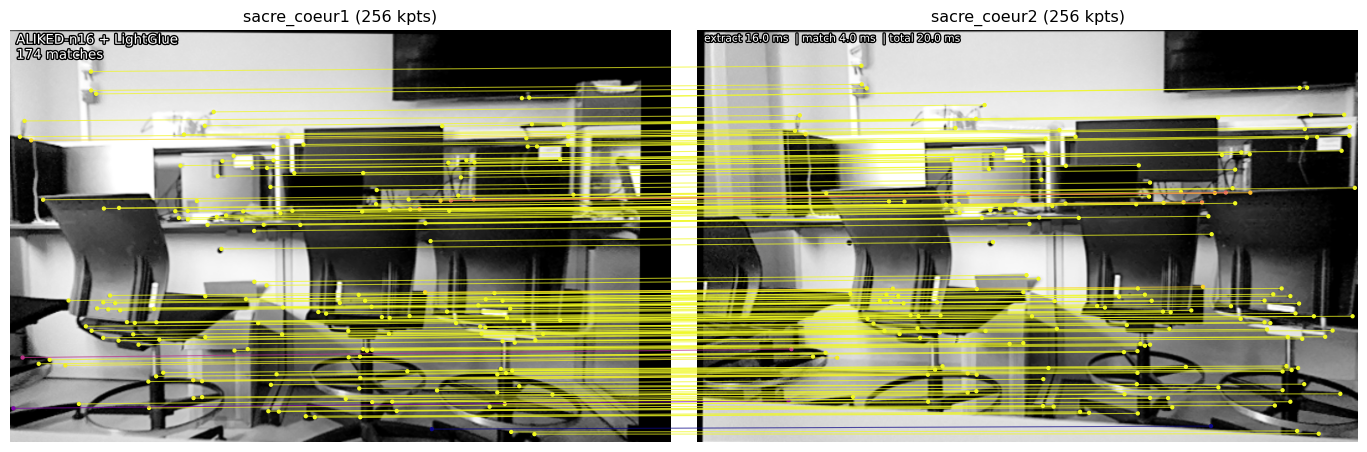

[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/raco_b2_h480_w768_k256_sim.fp16.engine
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/aliked_n16_describe_b2_h480_w768_k256_sim.fp16.engine
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/raco_lightglue_k256_sim.fp16.engine
RaCo + ALIKED-describe + LightGlue: 175 matches  |  extract 9.0 ms  | describe 18.8 ms  | match 3.9 ms  | total 31.8 ms


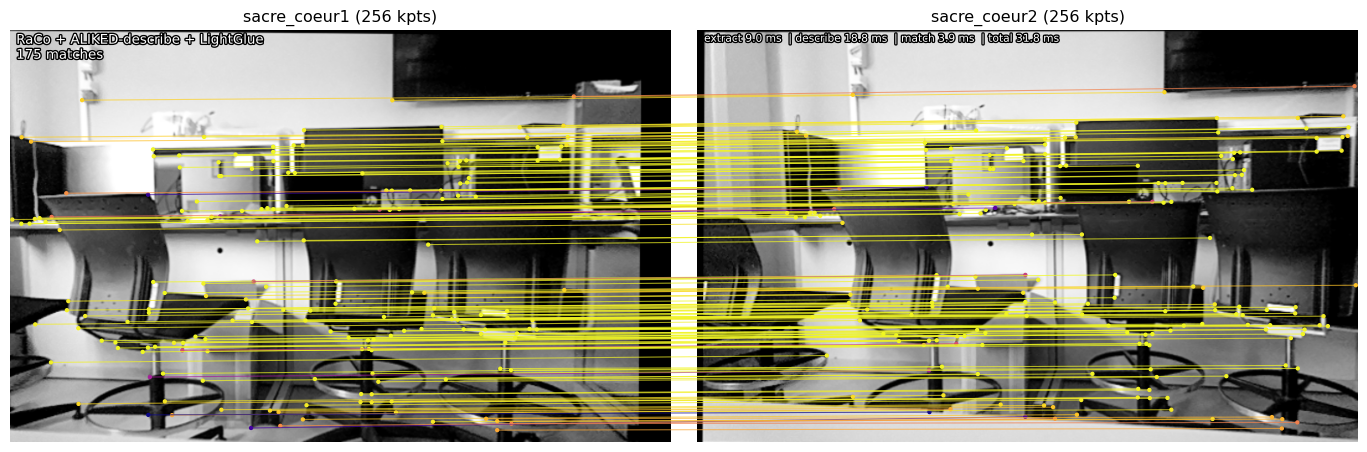

[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/xfeat_b2_h480_w768_k256_sim.fp16.engine
[I] Loading bytes from /home/ubuntu/Desktop/dl-vins-factory/LightGlue-ONNX-Jetson/weights/euroc/xfeat_lightglue_k256_sim.fp16.engine
xFeat + LighterGlue: 93 matches  |  extract 3.5 ms  | match 3.5 ms  | total 7.0 ms


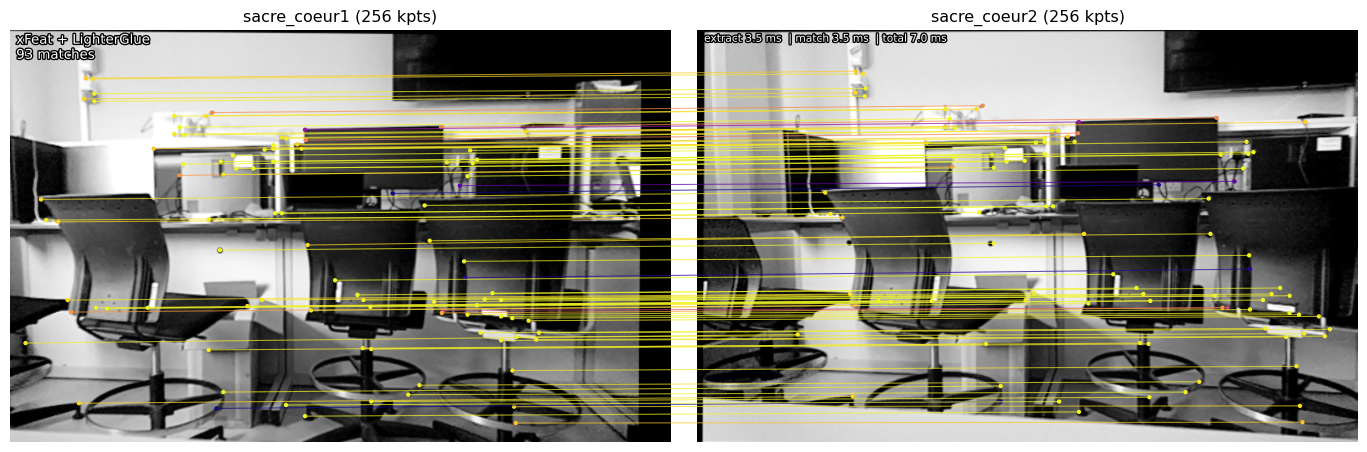

In [ ]:
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

from polygraphy.backend.common import BytesFromPath
from polygraphy.backend.trt import EngineFromBytes, TrtRunner

from lightglue_dynamo import viz
from lightglue_dynamo.extractor_export import EXTRACTOR_REGISTRY

# --- paths (only cell 1 needed) ---
K = 256
H, W = 480, 768
asset_dir = LG / "assets"

N_WARMUP = 5
N_TIMED  = 20

imgs_bgr = []
# for fname in ["sacre_coeur1.jpg", "sacre_coeur2.jpg"]:
# for fname in ["DSC_0410.JPG", "DSC_0411.JPG"]:
for fname in ["debug1.png", "debug2.png"]:
    p = asset_dir / fname
    if p.is_file():
        imgs_bgr.append(cv2.resize(cv2.imread(str(p)), (W, H)))
    else:
        print(f"[WARN] {fname} not found — using random noise")
        imgs_bgr.append(np.random.randint(0, 255, (H, W, 3), dtype=np.uint8))


def normalize_isotropic(kpts: np.ndarray, h: int, w: int) -> np.ndarray:
    shift = np.array([w, h], dtype=np.float32) / 2
    scale = max(w, h) / 2
    return ((kpts.astype(np.float32) - shift) / scale).astype(np.float32)


def run_extractor(engine_path, spec, images_bgr) -> tuple[dict, float]:
    frames = []
    for img in images_bgr:
        f = spec.preprocess(img)
        while f.ndim > 3:
            f = f[0]
        frames.append(f)
    x = np.stack(frames, axis=0).astype(np.float32)
    feed = {spec.input_name: x}
    with TrtRunner(EngineFromBytes(BytesFromPath(str(engine_path)))) as runner:
        for _ in range(N_WARMUP):
            runner.infer(feed_dict=feed)
        t0 = time.perf_counter()
        for _ in range(N_TIMED):
            out = runner.infer(feed_dict=feed)
        return out, (time.perf_counter() - t0) / N_TIMED


def run_describe(engine_path, feed_dict) -> tuple[dict, float]:
    with TrtRunner(EngineFromBytes(BytesFromPath(str(engine_path)))) as runner:
        for _ in range(N_WARMUP):
            runner.infer(feed_dict=feed_dict)
        t0 = time.perf_counter()
        for _ in range(N_TIMED):
            out = runner.infer(feed_dict=feed_dict)
        return out, (time.perf_counter() - t0) / N_TIMED


def kpts_to_pixels(kpts_b: np.ndarray, anisotropic: bool, h: int, w: int) -> np.ndarray:
    if anisotropic:
        size = np.array([w, h], dtype=np.float32)
        return (kpts_b.astype(np.float32) + 1.0) * size / 2.0
    return kpts_b.astype(np.float32)


# --- ALIKED describe helper (used only for the RaCo pipeline) ---
# The exported ALIKED TRT engine fuses SDDH sampling at its own detected keypoints
# and exposes no input port for external coordinates, so we use PyTorch directly.
_aliked_model_cache = None


def _get_aliked() -> torch.nn.Module:
    global _aliked_model_cache
    if _aliked_model_cache is None:
        from lightglue_dynamo.models.aliked.aliked import ALIKED as _ALIKED
        _aliked_model_cache = _ALIKED(
            model_name="aliked-n16",
            device="cpu",
            pretrained_path=str(WEIGHTS / "aliked-n16.pth"),
        ).eval()
    return _aliked_model_cache


def aliked_describe_at(kpts_px: np.ndarray, img_bgr: np.ndarray) -> np.ndarray:
    """ALIKED-SDDH descriptors at given pixel (x,y) keypoints."""
    aliked = _get_aliked()
    h, w = img_bgr.shape[:2]
    img_t = torch.from_numpy(
        img_bgr[..., ::-1].astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0)
    wh = torch.tensor([[w - 1, h - 1]], dtype=torch.float32)
    kpts_n = 2.0 * torch.from_numpy(kpts_px.astype(np.float32)) / wh - 1.0
    with torch.no_grad():
        feature_map, _ = aliked.extract_dense_map(img_t)
        descs_list, _ = aliked.desc_head(feature_map, [kpts_n])
    return descs_list[0].cpu().numpy()


def _stem_to_eid(stem: str):
    for eid in sorted(EXTRACTOR_REGISTRY, key=len, reverse=True):
        if stem.startswith(eid):
            return eid
    return None


# ---------------------------------------------------------------------------
# Pipeline registry
# (label, extractor_engine, matcher_engine, anisotropic, raco_describe)
# All engine filenames are relative to OUT_DIR.
# ---------------------------------------------------------------------------
PIPELINES = [
    ("SuperPoint + LightGlue",
     f"superpoint_open_b2_h{H}_w{W}_k{K}_sim.fp16.engine",
     f"superpoint_lightglue_k{K}_sim.fp16.engine",
     None, False, False),
    ("ALIKED-n16 + LightGlue",
     f"aliked_n16_b2_h{H}_w{W}_k{K}_sim.fp16.engine",
     f"aliked_lightglue_k{K}_sim.fp16.engine",
     None, True, False),
    ("RaCo + ALIKED-describe + LightGlue",
     f"raco_b2_h{H}_w{W}_k{K}_sim.fp16.engine",
     f"raco_lightglue_k{K}_sim.fp16.engine",
     f"aliked_n16_describe_b2_h{H}_w{W}_k{K}_sim.fp16.engine",
     False, True),
    ("xFeat + LighterGlue",
     f"xfeat_b2_h{H}_w{W}_k{K}_sim.fp16.engine",
     f"xfeat_lightglue_k{K}_sim.fp16.engine",
     None, False, False),
]


for label, ext_stem, mat_stem, desc_stem, aniso, raco_describe in PIPELINES:
    ext_path   = OUT_DIR / ext_stem
    match_path = OUT_DIR / mat_stem

    if not ext_path.is_file():
        print(f"[SKIP] {label}: extractor engine not found ({ext_stem})")
        continue
    if not match_path.is_file():
        print(f"[SKIP] {label}: matcher engine not found ({mat_stem})")
        continue

    t_describe = 0.0

    if raco_describe:
        raco_spec = EXTRACTOR_REGISTRY["raco"]
        ext_out, t_extract = run_extractor(ext_path, raco_spec, imgs_bgr)

        kpts_px = ext_out["keypoints"].astype(np.float32)   # (2, K, 2) pixel-space
        n0 = n1 = kpts_px.shape[1]

        wh_norm = np.array([W - 1, H - 1], dtype=np.float32)
        kpts_n_b = 2.0 * kpts_px / wh_norm - 1.0  # (2, K, 2) anisotropic
        imgs_rgb_nchw = np.stack(
            [img[..., ::-1].astype(np.float32) / 255.0 for img in imgs_bgr], axis=0
        ).transpose(0, 3, 1, 2)  # (2, 3, H, W)
        desc_feed = {"image": imgs_rgb_nchw, "kpts_n": kpts_n_b}
        desc_path = (OUT_DIR / desc_stem) if desc_stem else None

        if desc_path is not None and desc_path.is_file():
            desc_out, t_describe = run_describe(desc_path, desc_feed)
            descs_b = desc_out["descriptors"]  # (2, K, 128)
        else:
            print(f"  [WARN] {label}: describe engine missing — PyTorch fallback")
            t0 = time.perf_counter()
            descs0 = aliked_describe_at(kpts_px[0], imgs_bgr[0])
            descs1 = aliked_describe_at(kpts_px[1], imgs_bgr[1])
            t_describe = time.perf_counter() - t0
            descs_b = np.stack([descs0, descs1], axis=0)
    else:
        eid = _stem_to_eid(ext_stem.replace("_sim.fp16.engine", ""))
        if eid is None:
            print(f"[SKIP] {label}: cannot resolve extractor id from {ext_stem!r}")
            continue
        spec    = EXTRACTOR_REGISTRY[eid]
        ext_out, t_extract = run_extractor(ext_path, spec, imgs_bgr)

        kpts_b   = ext_out["keypoints"]
        descs_b  = ext_out["descriptors"]
        scores_b = ext_out["keypoint_scores"]
        num_b    = ext_out.get("num_keypoints")
        n0 = int(num_b[0]) if num_b is not None else int((scores_b[0] > 0).sum())
        n1 = int(num_b[1]) if num_b is not None else int((scores_b[1] > 0).sum())
        kpts_px  = kpts_to_pixels(kpts_b, aniso, H, W)

    # --- Matcher (TRT) ---
    kpts0_n = normalize_isotropic(kpts_px[0], H, W)[None]
    kpts1_n = normalize_isotropic(kpts_px[1], H, W)[None]
    desc0   = descs_b[0:1].astype(np.float32)
    desc1   = descs_b[1:2].astype(np.float32)

    feed_mat = {"kpts0": kpts0_n, "kpts1": kpts1_n, "desc0": desc0, "desc1": desc1}
    with TrtRunner(EngineFromBytes(BytesFromPath(str(match_path)))) as runner:
        for _ in range(N_WARMUP):
            runner.infer(feed_dict=feed_mat)
        t0 = time.perf_counter()
        for _ in range(N_TIMED):
            m_out = runner.infer(feed_dict=feed_mat)
        t_match = (time.perf_counter() - t0) / N_TIMED

    matches0 = m_out["matches0"]
    mscores0 = m_out["mscores0"]

    valid    = (matches0[:, 0] < n0) & (matches0[:, 1] < n1)
    matches0 = matches0[valid]
    mscores0 = mscores0[valid]

    mkpts0 = kpts_px[0][matches0[:, 0]]
    mkpts1 = kpts_px[1][matches0[:, 1]]

    # --- Timing summary ---
    if t_describe > 0:
        timing_str = (
            f"extract {t_extract*1e3:.1f} ms"
            f"  | describe {t_describe*1e3:.1f} ms"
            f"  | match {t_match*1e3:.1f} ms"
            f"  | total {(t_extract + t_describe + t_match)*1e3:.1f} ms"
        )
    else:
        timing_str = (
            f"extract {t_extract*1e3:.1f} ms"
            f"  | match {t_match*1e3:.1f} ms"
            f"  | total {(t_extract + t_match)*1e3:.1f} ms"
        )
    print(f"{label}: {len(matches0)} matches  |  {timing_str}")

    # --- Visualise ---
    viz.plot_images(imgs_bgr, titles=[f"image1 ({n0} kpts1)",
                                      f"image2 ({n1} kpts)"], dpi=96)
    if len(matches0) > 0:
        colors = plt.cm.plasma(
            (mscores0 - mscores0.min()) / max(mscores0.max() - mscores0.min(), 1e-6)
        ).tolist()
        viz.plot_matches(mkpts0, mkpts1, color=colors, lw=0.8, a=0.7, ps=5)
    viz.add_text(0, f"{label}\n{len(matches0)} matches", fs=10)
    viz.add_text(1, timing_str, fs=8)
    plt.show()
